<a href="https://colab.research.google.com/github/marescost4/Mariane-David-Fillipy/blob/main/tarefa7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Bioestatística - Tarefa 07



*   Mariane Santana 16890981
*   David Souza 16965966
*   Fillipy Leal 17097358



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr
import statsmodels.api as sm

pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 3)

df = pd.read_csv ('Tarefa_Semana4.csv', sep='\t')
df.head (90)

,pH,Biomass,Species
0,high,0.469,30
1,high,1.731,39
2,high,2.090,44
3,high,3.926,35
4,high,4.367,25
...,...,...,...
85,low,2.326,8
86,low,2.996,12
87,low,3.538,14
88,low,4.365,7


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   pH       90 non-null     object 
 1   Biomass  90 non-null     float64
 2   Species  90 non-null     int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 2.2+ KB


In [ ]:
df["pH"].value_counts()

,count
pH,
high,30
mid,30
low,30


In [ ]:
df.groupby("pH")["Species"].agg(["mean", "std", "min", "max"])

,mean,std,min,max
pH,,,,
high,26.800,9.658,7,44
low,11.567,5.354,2,19
mid,20.000,6.716,6,31


In [ ]:
df["pH_num"] = df["pH"].map({"low": 1,"mid": 2,"high": 3})

df.head(90)

,pH,Biomass,Species,pH_num
0,high,0.469,30,3
1,high,1.731,39,3
2,high,2.090,44,3
3,high,3.926,35,3
4,high,4.367,25,3
...,...,...,...,...
85,low,2.326,8,1
86,low,2.996,12,1
87,low,3.538,14,1
88,low,4.365,7,1


In [ ]:
df[["pH", "pH_num"]].head(90)

,pH,pH_num
0,high,3
1,high,3
2,high,3
3,high,3
4,high,3
...,...,...
85,low,1
86,low,1
87,low,1
88,low,1


## 1- Como se apresenta graficamente a relação entre a quantidade de biomassa e o número de espécies de plantas?

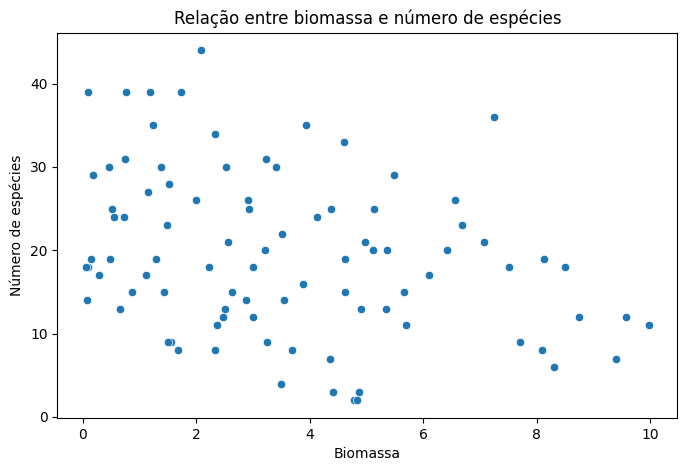

In [ ]:
import seaborn as sns
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df,x="Biomass",y="Species")

plt.xlabel("Biomassa")
plt.ylabel("Número de espécies")
plt.title("Relação entre biomassa e número de espécies")

plt.show()

## 2- O gráfico de dispersão sugere uma associação positiva, negativa ou inexistente entre biomassa e número de espécies?

R: O gráfico de dispersão sugere uma associação negativa, isso significa que à medida que a biomassa aumenta o número de espécies tende a dimuinuir. Essa associação é relativamente fraca, sendo confirmada pelo coeficiente de correlação de Pearson (r=-0,317) onde o r é negativo, sendo assim a associação é negativa.

In [22]:
r_biomass, p_biomass = pearsonr(df["Biomass"],df["Species"])

print("Correlação de Pearson:", r_biomass)

Correlação de Pearson: -0.3171136204583374


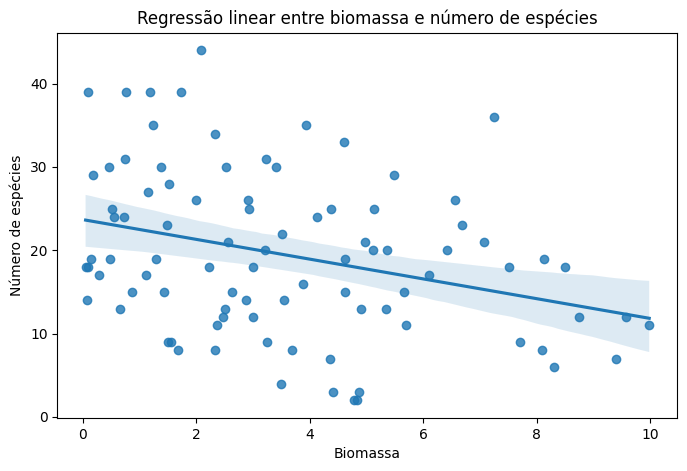

In [24]:
plt.figure(figsize=(8, 5))

sns.regplot(data=df,x="Biomass",y="Species",ci=95)

plt.xlabel("Biomassa")
plt.ylabel("Número de espécies")
plt.title("Regressão linear entre biomassa e número de espécies")

plt.show()

## 3- Existe evidência de uma relação linear entre valores do pH e o número de espécies de plantas?

R:Sim, os dados sugerem uma relação linear positiva entre os níveis de pH (baixo = 1, médio = 2 e alto = 3) e o número de espécies. O número médio de espécies aumenta conforme o pH passa de baixo para médio e de médio para alto. As médias observadas foram de aproximadamente 11,57 espécies para pH baixo, 20 espécies para pH médio e 26,80 espécies para pH alto.


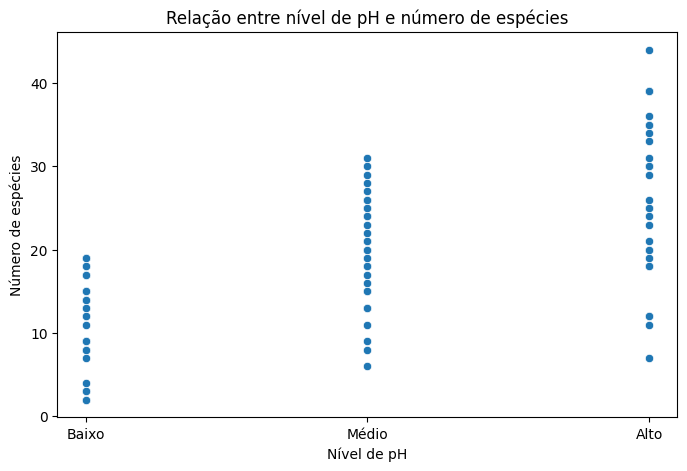

In [26]:
df["pH_num"] = df["pH"].map({"low": 1,"mid": 2,"high": 3})
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df,x="pH_num",y="Species")

plt.xticks([1, 2, 3],["Baixo","Médio","Alto"])

plt.xlabel("Nível de pH")
plt.ylabel("Número de espécies")
plt.title("Relação entre nível de pH e número de espécies")

plt.show()

In [29]:
media_por_ph = df.groupby('pH')['Species'].mean()
print("Média de espécies para cada nível de pH:\n", media_por_ph)

Média de espécies para cada nível de pH:
 pH
high    26.800
low     11.567
mid     20.000
Name: Species, dtype: float64


In [28]:
import statsmodels.formula.api as smf

modelo_ph = smf.ols("Species ~ pH_num",data=df).fit()

print(modelo_ph.summary())

                            OLS Regression Results                            
Dep. Variable:                Species   R-squared:                       0.417
Model:                            OLS   Adj. R-squared:                  0.411
Method:                 Least Squares   F-statistic:                     63.06
Date:                Thu, 27 Aug 2026   Prob (F-statistic):           6.11e-12
Time:                        02:40:35   Log-Likelihood:                -307.19
No. Observations:                  90   AIC:                             618.4
Df Residuals:                      88   BIC:                             623.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.2222      2.072      2.038      0.0

## 4- É possível utilizar um modelo de regressão linear simples para prever o número de espécies a partir da quantidade de biomassa? Construa

R: Sim. É possível, considerando a biomassa como variável independente (X) e o número de espécies como variável dependente (Y).

O coeficiente angular negativo indica que, o aumento da biomassa está associado a uma redução no número de espécies. O coeficiente de correlação de Pearson foi r = -0,3171, indicando uma associação negativa fraca. O coeficiente de determinação foi R² = 0,1006, indicando que aproximadamente 10,06% da variação no número de espécies é explicada pela biomassa no modelo linear.


O modelo de regressão linear simples tem a forma:

$$ Y = \beta_0 + \beta_1X + \varepsilon $$

Neste caso:

Y = número de espécies (Species)

X = quantidade de biomassa (Biomass)

$ \beta_0$  = intercepto

$\beta_1$ = coeficiente da biomassa

In [34]:
from scipy.stats import linregress

X = df["Biomass"]
Y = df["Species"]

resultado = linregress(X, Y)

# Coeficientes
a = resultado.intercept
b = resultado.slope
r = resultado.rvalue
p = resultado.pvalue
r2 = r**2

print("Intercepto (a):", a)
print("Coeficiente angular/de biomassa (b):", b)
print("Correlação de Pearson (r):", r)
print("Valor-p:", p)
print("Coeficiente de determinação (R²):", r2)

Intercepto (a): 23.675543953867273
Coeficiente angular/de biomassa (b): -1.1863870325265053
Correlação de Pearson (r): -0.3171136204583372
Valor-p: 0.0023240064396025553
Coeficiente de determinação (R²): 0.10056104828019433


In [35]:
print(f"\nEquação do modelo: Ŷ = {intercepto:.4f} "f"+ ({coef_biomassa:.4f}) × Biomassa")


Equação do modelo: Ŷ = 23.6755 + (-1.1864) × Biomassa


## 5- Qual é a equação da reta de regressão que relaciona o número de espécies à quantidade de pH?

R: Considera-se os níveis de PH como variável numérica ordinal (low = 1, mid = 2 e high = 3)

O coeficiente positivo (7,6167) indica que, a cada aumento de um nível na escala de pH utilizada, o número esperado de espécies aumenta aproximadamente 7,62 espécies. O coeficiente de determinação é de aproximadamente R² = 0,4174, indicando que cerca de 41,74% da variação no número de espécies é explicada pelo nível de pH.

Se low, mid e high forem tratadas apenas como categorias, então não devemos construir uma reta de regressão linear simples usando pH como X, porque essas categorias não são valores numéricos de pH.

In [38]:
resultado = linregress(df["pH_num"], df["Species"])

a = resultado.intercept
b = resultado.slope

print("Intercepto (a):", a)
print("Coeficiente angular (b):", b)

print(f"\nEquação da reta:")
print(f"Species = {a:.4f} + {b:.4f} × pH")

Intercepto (a): 4.222222222222204
Coeficiente angular (b): 7.616666666666676

Equação da reta:
Species = 4.2222 + 7.6167 × pH


## 6- Qual é o valor estimado do intercepto da regressão entre biomassa e número de espécies e como ele pode ser interpretado?

R: O valor estimado do intercepto é 23.6755. Isso significa que, teoricamente, quando a biomassa é zero, o número médio de espécies esperado seria de aproximadamente 23.68.

In [40]:
print("Intercepto =", intercepto)

Intercepto = 23.675543953867273


## 7- Qual é o valor estimado do coeficiente de inclinação da regressão e o que ele indica sobre a mudança esperada no número de espécies para cada unidade adicional de biomassa?

R: O valor estimado do coeficiente de inclinação para 'Biomass' é -1.1864. Isso indica que para cada unidade de aumento na biomassa, o número de espécies esperado diminui em aproximadamente 1.1864 unidades.

In [42]:
inclinacao = b

print("Coeficiente de inclinação =", inclinacao)

Coeficiente de inclinação = 7.616666666666676


## 8- A quantidade de biomassa apresenta efeito significativo sobre o número de espécies de plantas?

R: Sim. A quantidade de biomassa apresenta efeito sigificativo nessa questão. O coeficiente de inclinação da regressão foi negativo ($\beta_1$=-1,1864), indicando que o aumento da biomassa está associado à redução do número de espécies. Além disso, o intervalo de confiança de 95% para o coeficiente não inclui zero, fornecendo evidência de que o efeito da biomassa é estatisticamente diferente de zero.

In [43]:
# Mostrar os coeficientes do modelo
print(modelo.params)
# Intervalo de confiança de 95% dos coeficientes
print(modelo.conf_int())

const      23.676
Biomass    -1.186
dtype: float64
              0       1
const    20.376  26.975
Biomass  -1.938  -0.435


In [44]:
# Coeficiente da Biomassa
coef = modelo.params["Biomass"]

# Intervalo de confiança de 95%
limite_inferior = modelo.conf_int().loc["Biomass", 0]
limite_superior = modelo.conf_int().loc["Biomass", 1]

print("Coeficiente da Biomassa:", coef)
print("Intervalo de confiança:")
print(limite_inferior, "a", limite_superior)

Coeficiente da Biomassa: -1.1863870325265062
Intervalo de confiança:
-1.9380397336397799 a -0.4347343314132325


## 9- Quanto da variação observada no número de espécies pode ser explicada pelos valores do pH por meio do modelo de regressão linear?

R: Aproximadamente 41,7% da variação observada no número de espécies é explicada pelo modelo linear baseado nos níveis de pH.

In [45]:
r2_ph = modelo_ph.rsquared

print("R² =", r2_ph)
print("Porcentagem explicada =", r2_ph * 100, "%")

R² = 0.41744808774480335
Porcentagem explicada = 41.74480877448033 %


## 10- Existe correlação linear significativa entre a quantidade de biomassa e o número de espécies de plantas?

R: Sim, o coeficiente de correlação de Pearson foi aproximadamente (r=-0,317), indicando uma correlação negativa de intensidade fraca a moderada. Isso significa que, nos dados analisados, maiores quantidades de biomassa tendem a estar associadas a menores números de espécies. Além disso, o intervalo de confiança de 95% para o coeficiente de correlação não inclui zero, indicando evidência de uma associação linear diferente de zero.

In [48]:
r, _ = pearsonr(df["Biomass"], df["Species"])

print("Coeficiente de correlação de Pearson (r):", r)

# Número de observações
n = len(df)

# Transformação de Fisher
z = np.arctanh(r)

# Intervalo de confiança de 95%
z_inferior = z - 1.96 * erro
z_superior = z + 1.96 * erro

# Retornar para a escala da correlação
r_inferior = np.tanh(z_inferior)
r_superior = np.tanh(z_superior)

print("Correlação de Pearson:", round(r, 4))
print("IC 95%:", round(r_inferior, 4), "a", round(r_superior, 4))

Coeficiente de correlação de Pearson (r): -0.3171136204583374
Correlação de Pearson: -0.3171
IC 95%: -0.4919 a -0.1178


## 11- Qual é a intensidade e a direção da correlação linear de Pearson entre pH e o número de espécies?

R: A correlação linear de Pearson entre o nível de pH e o número de espécies foi de aproximadamente r = 0,646. Esse valor indica uma correlação positiva de intensidade moderada, mostrando que parcelas com níveis mais elevados de pH tendem a apresentar maior número de espécies de plantas. Além disso, o intervalo de confiança de 95% do coeficiente não inclui o valor zero, fornecendo evidência de uma associação linear positiva entre o pH e o número de espécies.

In [51]:
# Número de observações
n = len(df)

# Transformação de Fisher
z = np.arctanh(r)

# Erro padrão da transformação
erro_padrao = 1 / np.sqrt(n - 3)

# Limites do intervalo de confiança (95%)
z_inf = z - 1.96 * erro_padrao
z_sup = z + 1.96 * erro_padrao

# Converter novamente para correlação
r_inf = np.tanh(z_inf)
r_sup = np.tanh(z_sup)

print("Correlação de Pearson:", round(r, 4))
print("IC 95%:", round(r_inf, 4), "a", round(r_sup, 4))

Correlação de Pearson: -0.3171
IC 95%: -0.4919 a -0.1178
